In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
df = pd.read_csv("USBillionDollarEvents_1980to2025.csv", nrows=425)
# Drop all columns after "Summary"
summary_idx = df.columns.get_loc("Summary")
df = df.iloc[:, :summary_idx + 1]

In [26]:
df_scs = df[df['Disaster Type'] == 'severe storm']

In [35]:
grouped = df_scs.groupby('year start')['Cost (CPI-Adjusted, Billions)'].sum()

In [36]:
grouped

year start
1981     1.45
1982     3.28
1984     3.31
1985     1.81
1986     1.57
1989     1.45
1990     2.04
1991     1.55
1992     7.33
1993     1.44
1994     2.17
1995    12.91
1997     4.00
1998     7.30
1999     3.92
2000     1.30
2001     6.89
2002     5.06
2003    14.12
2004     2.92
2005     1.45
2006    11.28
2007     3.94
2008    13.60
2009    12.12
2010    13.34
2011    46.23
2012    23.02
2013    14.94
2014    16.31
2015    11.19
2016    19.68
2017    25.46
2018    17.39
2019    17.48
2020    41.84
2021    23.85
2022    23.59
2023    56.94
2024    47.92
2025    49.93
Name: Cost (CPI-Adjusted, Billions), dtype: float64

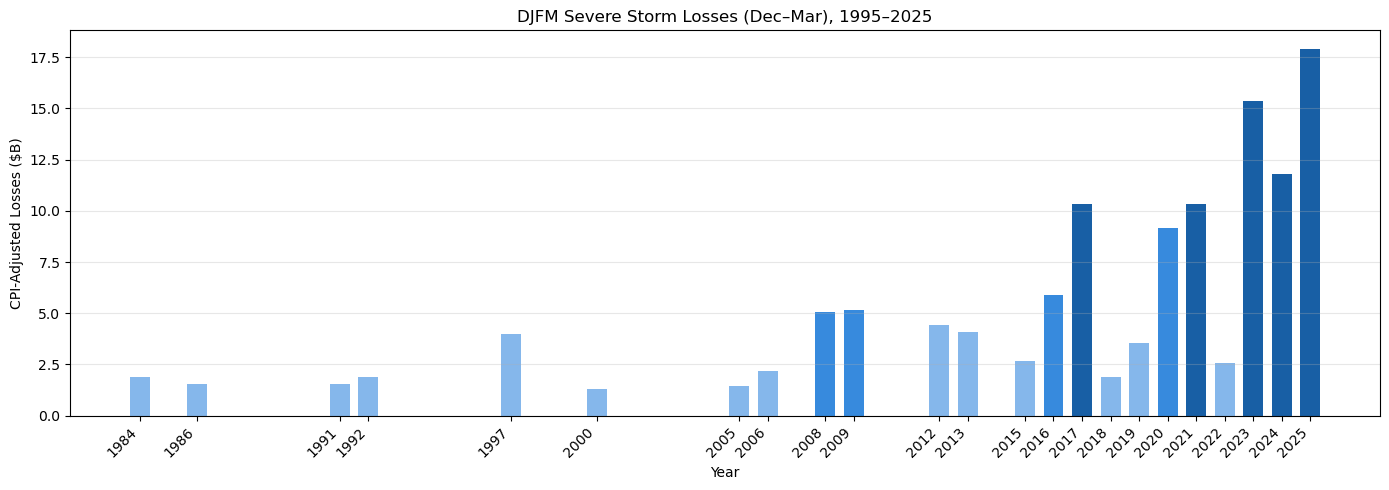

In [41]:

# Filter: severe storms, DJFM only
mask = (df_scs["Is DJFM?"] == 1)



#filtered = df[mask].copy()
plot_df = df_scs[mask].copy()

# Sum CPI-adjusted losses by year
annual = (
    plot_df.groupby('year start')['Cost (CPI-Adjusted, Billions)']
    .sum()
)

# Color bars by magnitude
colors = ["#185FA5" if v >= 10 else "#378ADD" if v >= 5 else "#85B7EB" for v in annual]

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(annual.index, annual.values, color=colors, width=0.7)

ax.set_xlabel("Year")
ax.set_ylabel("CPI-Adjusted Losses ($B)")
ax.set_title("DJFM Severe Storm Losses (Dec–Mar), 1995–2025")
ax.set_xticks(annual.index)
ax.set_xticklabels(annual.index, rotation=45, ha="right")
#ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:.0f}B"))
ax.grid(axis="y", alpha=0.3)
#ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
#plt.savefig("djfm_storm_losses.png", dpi=150)
plt.show()

In [38]:
annual

year start
1981     1.45
1982     3.28
1984     3.31
1985     1.81
1986     1.57
1989     1.45
1990     2.04
1991     1.55
1992     7.33
1993     1.44
1994     2.17
1995    12.91
1997     4.00
1998     7.30
1999     3.92
2000     1.30
2001     6.89
2002     5.06
2003    14.12
2004     2.92
2005     1.45
2006    11.28
2007     3.94
2008    13.60
2009    12.12
2010    13.34
2011    46.23
2012    23.02
2013    14.94
2014    16.31
2015    11.19
2016    19.68
2017    25.46
2018    17.39
2019    17.48
2020    41.84
2021    23.85
2022    23.59
2023    56.94
2024    47.92
2025    49.93
Name: Cost (CPI-Adjusted, Billions), dtype: float64